In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
# matplotlib.patches allows us create colored patches, we can use for legends in plots
import matplotlib.patches as mpatches
# seaborn also builds on matplotlib and adds graphical features and new plot types
import requests
import seaborn as sns
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

## Loading DSM from CSV files

In [2]:
import pandas as pd

freq_csv_path = "consolidation_potential_DSM_scenario1_interaction_frequency.csv"
consol_csv_path = "consolidation_potential_DSM_scenario1_SA4_FTE2_2026-08-04-12h27.csv"

# Load interaction frequency DSM (unit names as row and column labels)
DSM_freq = pd.read_csv(freq_csv_path, index_col=0)

# Load consolidation potential DSM
# The CSV has a two-row header: row 0 = functional abbreviations, row 1 = full unit names
# Column 0 = abbreviations, column 1 = full unit names (row labels), columns 2+ = data
consol_raw = pd.read_csv(consol_csv_path, header=None)
col_names = consol_raw.iloc[1, 2:].tolist()
row_names = consol_raw.iloc[2:, 1].tolist()
DSM_consol = pd.DataFrame(
    consol_raw.iloc[2:, 2:].values,
    index=row_names,
    columns=col_names,
    dtype=float
)

# Align both matrices to the same sorted unit order
units = sorted(DSM_freq.index.tolist())
DSM_freq = DSM_freq.loc[units, units]
DSM_consol = DSM_consol.loc[units, units]

DSM = DSM_freq  # interaction frequency is the primary DSM for clustering (S1/S2)
DSM_header_list = DSM.columns.tolist()

# Export filename derived from consolidation CSV filename
csv_file = consol_csv_path.replace(".csv", "")

In [3]:
import numpy as np

def style_freq(df):
    # Mask the diagonal so self-interactions don't skew the colour scale
    vals = df.values.astype(float).copy()
    np.fill_diagonal(vals, np.nan)
    vmax = np.nanmax(vals)
    cmap = plt.cm.YlOrRd

    styled = pd.DataFrame('', index=df.index, columns=df.columns)
    for i in range(len(df)):
        for j in range(len(df.columns)):
            if i == j:
                styled.iloc[i, j] = 'background-color: #f0f0f0'
            elif df.iloc[i, j] > 0:
                intensity = df.iloc[i, j] / vmax
                colour = mcolors.rgb2hex(cmap(intensity))
                styled.iloc[i, j] = f'background-color: {colour}'
    return styled

DSM_freq.style.apply(style_freq, axis=None)

,Clinical Research Division,Clinical Strategy Division,Clinical Strategy Group,Medical Communications Office,Medical Evaluation Unit 1,Medical Evaluation Unit 2,Medical Evaluation Unit 3,Medical Excellence Office,Medical Excellence Team,Medical Governance Office,Medical Governance Unit,Medical Innovation Group,Medical Research Evaluation,Medical Scientific Information Center,New Product Value Planning,Operational Effectiveness,Operational Excellence,Post-Marketing Study Strategy Management,Product Management Review,Regulatory Affairs Unit 1,Regulatory Affairs Unit 2,Regulatory Affairs Unit 3,Scientific Information Center,Strategic Management Office 1,Strategic Management Office 2,Strategic Management Office 3,Strategic Management Team 1,Strategic Management Team 2,Strategic Management Team 3,Strategic Medical Excellence
Clinical Research Division,4.370000,4.790000,2.000000,0.000000,1.500000,3.270000,1.000000,0.000000,0.000000,1.320000,0.000000,1.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.170000,6.050000,3.580000,2.440000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Clinical Strategy Division,4.740000,3.890000,5.500000,0.000000,1.400000,2.360000,1.000000,0.000000,0.000000,1.580000,0.000000,4.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,4.750000,4.710000,3.210000,1.000000,0.000000,1.400000,0.000000,0.000000,0.000000,0.000000,0.000000
Clinical Strategy Group,2.000000,5.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Medical Communications Office,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.000000,4.000000,0.000000,2.670000,0.000000,2.000000,12.000000,6.000000,2.000000,0.000000,0.000000,15.000000,1.500000,6.250000,7.000000,3.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
Medical Evaluation Unit 1,1.500000,1.400000,0.000000,2.000000,6.240000,4.700000,3.530000,5.500000,6.220000,1.310000,1.710000,3.100000,0.000000,1.000000,4.250000,0.000000,0.000000,2.000000,1.000000,8.950000,6.000000,10.000000,3.820000,1.330000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000
Medical Evaluation Unit 2,3.400000,2.290000,0.000000,0.000000,4.700000,6.410000,4.500000,5.500000,4.000000,1.140000,2.000000,0.000000,2.000000,0.000000,1.290000,0.000000,0.000000,1.500000,1.000000,10.000000,7.660000,1.330000,3.000000,2.000000,1.500000,0.000000,0.000000,0.000000,0.000000,0.000000
Medical Evaluation Unit 3,1.000000,0.000000,0.000000,1.000000,3.530000,5.000000,5.440000,10.000000,2.000000,1.000000,4.250000,2.000000,0.000000,0.000000,1.100000,0.000000,1.000000,2.000000,0.000000,4.670000,3.000000,6.900000,3.130000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
Medical Excellence Office,0.000000,0.000000,0.000000,4.000000,4.330000,5.500000,10.000000,0.000000,0.000000,0.000000,0.000000,1.500000,0.000000,2.000000,0.000000,0.000000,0.000000,10.000000,1.000000,3.330000,4.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000
Medical Excellence Team,0.000000,0.000000,0.000000,0.000000,8.670000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.130000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Medical Governance Office,1.280000,1.880000,0.000000,3.000000,1.250000,1.250000,1.000000,0.000000,0.000000,7.330000,6.000000,3.430000,1.330000,0.000000,1.500000,0.000000,1.380000,2.130000,1.500000,2.000000,1.670000,1.290000,1.330000,1.250000,1.800000,1.600000,0.000000,1.000000,0.000000,13.500000


In [4]:
def style_consol(df):
    styled = pd.DataFrame('', index=df.index, columns=df.columns)
    for i in range(len(df)):
        for j in range(len(df.columns)):
            if i == j:
                styled.iloc[i, j] = 'background-color: #f0f0f0'
            elif df.iloc[i, j] == 1:
                styled.iloc[i, j] = 'background-color: #6fa8dc'
    return styled

DSM_consol.style.apply(style_consol, axis=None)

,Clinical Research Division,Clinical Strategy Division,Clinical Strategy Group,Medical Communications Office,Medical Evaluation Unit 1,Medical Evaluation Unit 2,Medical Evaluation Unit 3,Medical Excellence Office,Medical Excellence Team,Medical Governance Office,Medical Governance Unit,Medical Innovation Group,Medical Research Evaluation,Medical Scientific Information Center,New Product Value Planning,Operational Effectiveness,Operational Excellence,Post-Marketing Study Strategy Management,Product Management Review,Regulatory Affairs Unit 1,Regulatory Affairs Unit 2,Regulatory Affairs Unit 3,Scientific Information Center,Strategic Management Office 1,Strategic Management Office 2,Strategic Management Office 3,Strategic Management Team 1,Strategic Management Team 2,Strategic Management Team 3,Strategic Medical Excellence
Clinical Research Division,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Clinical Strategy Division,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Clinical Strategy Group,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Medical Communications Office,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Medical Evaluation Unit 1,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Medical Evaluation Unit 2,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Medical Evaluation Unit 3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Medical Excellence Office,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
Medical Excellence Team,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
Medical Governance Office,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


# Definition of 3 term Fitness function with consolidation

### Metric used is the Minimum Description length Principle defined in: Tian-Li Yu , Ali A. Yassine, David E. Goldberg paper - Eqation 3 - MDL clustering metric
### fDSM(M) = (1 - alpha - beta) * (Nc * log(Nn) + (log(Nn)*SUM_i_to_Nc(CLi)) + (alpha * [|S1| * (2log(Nn + 1))] + beta[|S2| * (2log(Nn + 1))])

##### Nc = number of clusters in the DSM
##### Nn = number of rows/columns in the DSM (ie. DSM elements such as number of roles in organization)
##### CLi = number of nodes in cluster i
##### S1 = Sum(Type 1 error) - Type 1 error = Every relationship which is not included in a cluster is a type 1 error
##### S2 = Sum(Type 2 error) - Type 2 error = A node is included in a cluster, but there are directional relationships with other nodes in the 
##### S3= Sum(Type 3 error) - Type 3 error = Nodes that should be consolidated, but are not
##### cluster which are not present (ie each 0 weight between two nodes is a Type 2 error)
##### logarithm base in the equation is 2. The equation is designed to operate on a binary genome. Any weights should be normalized between 0 and 1

In [5]:
DSM_header_list

['Clinical Research Division',
 'Clinical Strategy Division',
 'Clinical Strategy Group',
 'Medical Communications Office',
 'Medical Evaluation Unit 1',
 'Medical Evaluation Unit 2',
 'Medical Evaluation Unit 3',
 'Medical Excellence Office',
 'Medical Excellence Team',
 'Medical Governance Office',
 'Medical Governance Unit',
 'Medical Innovation Group',
 'Medical Research Evaluation',
 'Medical Scientific Information Center',
 'New Product Value Planning',
 'Operational Effectiveness',
 'Operational Excellence',
 'Post-Marketing Study Strategy Management',
 'Product Management Review',
 'Regulatory Affairs Unit 1',
 'Regulatory Affairs Unit 2',
 'Regulatory Affairs Unit 3',
 'Scientific Information Center',
 'Strategic Management Office 1',
 'Strategic Management Office 2',
 'Strategic Management Office 3',
 'Strategic Management Team 1',
 'Strategic Management Team 2',
 'Strategic Management Team 3',
 'Strategic Medical Excellence']

In [6]:
# Use the consolidation potential matrix directly (already aligned on load)
consolidation_matrix = DSM_consol.values.tolist()

In [7]:
def evalDSMmin(individual):
    DSM_eval_list = DSM_eval.values.T.tolist()

    # Binarize interaction frequency: any interaction > 0 counts as a connection
    for column in range(len(DSM_eval_list)):
        for row in range(len(DSM_eval_list)):
            if DSM_eval_list[column][row] > 1:
                DSM_eval_list[column][row] = 1

    Nn = NUMBER_OF_DSM_ELEMENTS
    Nc = 0
    S1 = 0
    S2 = 0
    S3 = 0
    CLi = [0] * MAX_NUMBER_OF_CLUSTERS

    # Count elements per cluster
    for element_index in range(NUMBER_OF_DSM_ELEMENTS):
        CLi[individual[element_index]] += 1

    # Count number of clusters in use
    for cluster in CLi:
        if cluster > 0:
            Nc += 1

    for column_index in range(NUMBER_OF_DSM_ELEMENTS):
        for row_index in range(NUMBER_OF_DSM_ELEMENTS):
            if column_index != row_index:
                # Type 1 error: connection exists but units in different clusters
                if DSM_eval_list[column_index][row_index] != 0 and individual[column_index] != individual[row_index]:
                    S1 += 1
                # Type 2 error: no connection but units in same cluster
                if DSM_eval_list[column_index][row_index] == 0 and individual[column_index] == individual[row_index]:
                    S2 += 1
                # Type 3 error: consolidation potential but units in different clusters
                if individual[column_index] != individual[row_index]:
                    if CONSOLIDATION_MODE == 'once':
                        if column_index < row_index and (
                            consolidation_matrix[column_index][row_index] == 1 or
                            consolidation_matrix[row_index][column_index] == 1
                        ):
                            S3 += 1
                    elif CONSOLIDATION_MODE == 'directional':
                        S3 += consolidation_matrix[column_index][row_index]

    # Cluster size imbalance penalty: penalises high variance in cluster sizes
    # Zero when all clusters are equal size, grows as clusters become unbalanced
    ideal_size     = NUMBER_OF_DSM_ELEMENTS / TARGET_CLUSTERS
    size_imbalance = sum((CLi[c] - ideal_size) ** 2 for c in range(MAX_NUMBER_OF_CLUSTERS) if CLi[c] > 0) / TARGET_CLUSTERS

    MDL_weight = 1 - alpha - beta - gamma - delta
    MDL = Nc * math.log(Nn, 2) + (math.log(Nn, 2) * sum(CLi))
    log_factor = 2 * math.log(Nn + 1, 2)
    type_error_score = (
        alpha * S1 * log_factor +
        beta  * S2 * log_factor +
        gamma * S3 * log_factor +
        delta * size_imbalance
    )
    fitness = MDL_weight * MDL + type_error_score
    return [fitness]

# Optimization Altorithm

In [8]:
MAX_NUMBER_OF_CLUSTERS = 10
alpha = 0.15  # Weight for type 1 errors (connections across cluster boundaries)
beta  = 0.05  # Weight for type 2 errors (no connection within cluster)
gamma = 0.15  # Weight for type 3 errors (consolidation potential across clusters)
delta = 0.2  # Weight for cluster size imbalance penalty
TARGET_CLUSTERS = 10   # Ideal number of clusters — delta penalty is zero at this target
POPULATION_SIZE = 200
NUMBER_OF_GENERATOINS = 400
cxpb  = 0.5   # Crossover probability
mutpb = 0.1   # Mutation probability

# Consolidation mode:
#   'once'        — each unordered pair contributes 1 to S3 if either direction
#                   signals consolidation potential (less aggressive)
#   'directional' — each directed edge contributes separately, so pairs where
#                   both directions agree get double weight (more aggressive)
CONSOLIDATION_MODE = 'once'

In [9]:
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

# Accumulators for live progress plot (prefixed to avoid clashing with logbook variables)
_plot_gens = []
_plot_avg  = []
_plot_min  = []
_plot_max  = []

def update_plot():
    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(_plot_gens, _plot_avg, color="black", linewidth=1.5, label="Average")
    ax.plot(_plot_gens, _plot_min, color="red",   linewidth=1.5, label="Minimum")
    ax.plot(_plot_gens, _plot_max, color="green", linewidth=1.5, label="Maximum")
    ax.set_xlabel("Generation")
    ax.set_ylabel("Fitness")
    ax.legend(loc="upper right")
    ax.set_title(f"Evolution progress — generation {_plot_gens[-1]}")
    plt.tight_layout()
    plt.show()
    print(f"Gen {_plot_gens[-1]:4d} | Avg: {_plot_avg[-1]:.4f} | Min: {_plot_min[-1]:.4f} | Max: {_plot_max[-1]:.4f}")

In [10]:
### Parameters for the evolutionary algorithm ###
DSM_eval = DSM
DSM_head = DSM_header_list

checkpoint_file = csv_file + "_checkpoint.pkl"
checkpoint_logbook_file = csv_file + "_logbook.pkl"
NUMBER_OF_DSM_ELEMENTS = len(DSM_eval.columns)
print("Max number of clusters allowed: ", MAX_NUMBER_OF_CLUSTERS)
print("Number of elements in the organisation: ", NUMBER_OF_DSM_ELEMENTS)

genome_len = NUMBER_OF_DSM_ELEMENTS

Max number of clusters allowed:  10
Number of elements in the organisation:  30


In [11]:
import os
try:
    os.remove(checkpoint_file) # in case of resetting long running optimizations
    print("Deleted existing Checkpoint")
except FileNotFoundError as e:
    print("No checkpoint found")

No checkpoint found


### Optimization parameters

In [12]:
# DSM GA - Unweighted and ignores busses ###
import pickle
import deap as ea
import random
from random import sample
from functools import partial
from deap import creator, base, tools, algorithms
from numba import jit
from numpy import arange
from scoop import futures


ea.creator.create("FitnessMin", ea.base.Fitness, weights=(-1.0,))
ea.creator.create("Individual", list, fitness=ea.creator.FitnessMin)

toolbox = ea.base.Toolbox()
#toolbox.register("map", futures.map) #Set DEAP to run on a machine cluster using SCOOP

# An individual is defined as a list of cluster assignments. Each index matches the index of the DSM elements. 
# If the individual has index 2 set to 3 that means that element at index 2 in the DSM is assigned to cluster 3.
toolbox.register("attribute", random.randint, 0, MAX_NUMBER_OF_CLUSTERS-1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attribute, n=genome_len)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", evalDSMmin)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutUniformInt, indpb=0.05, low= 0, up=MAX_NUMBER_OF_CLUSTERS-1)
# Use elitism + normal ranking
toolbox.register("select", tools.selTournament, tournsize=5)

stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("min", np.min)
stats.register("max", np.max)
logbook = tools.Logbook()

### Optimization loop

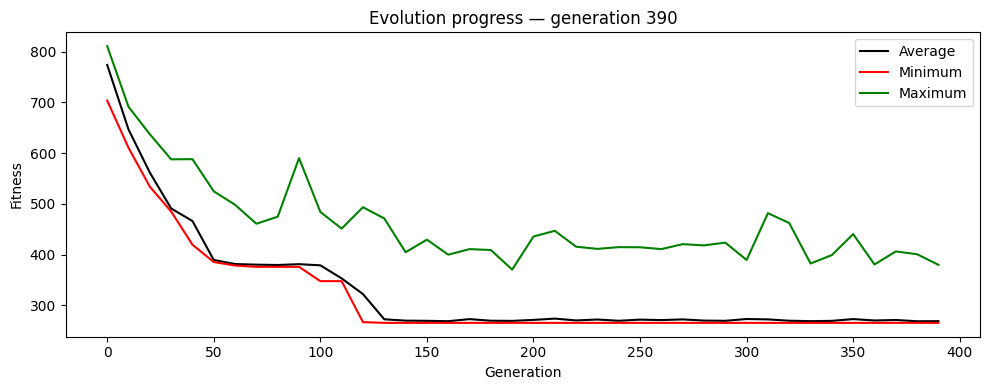

Gen  390 | Avg: 269.0794 | Min: 265.6676 | Max: 380.0842
Best solution found: [6, 6, 0, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 0, 5, 0, 6]
Final fitness: [265.66755325663667]


In [13]:
def run_evolution():
    hallOfFame = tools.HallOfFame(2)
    population = toolbox.population(n=POPULATION_SIZE)
    tools.initIterate(list, partial(sample, range(MAX_NUMBER_OF_CLUSTERS), MAX_NUMBER_OF_CLUSTERS))

    gen = 0
    while gen < NUMBER_OF_GENERATOINS:
        if gen == 0:
            try:
                checkpoint = pickle.load(open(checkpoint_file, "rb"))
                population = checkpoint["population"]
                gen = checkpoint["generation"]
                random.setstate(checkpoint["rndstate"])
                print("Checkpoint found, starting from generation", gen)
            except IOError:
                print("No checkpoint found, starting from scratch")

        # Update population
        population = toolbox.select(population, k=len(population))
        population = [toolbox.clone(ind) for ind in population]
        population = ea.algorithms.varAnd(population, toolbox, cxpb=cxpb, mutpb=mutpb)

        offspring = [ind for ind in population if not ind.fitness.valid]
        fits = toolbox.map(toolbox.evaluate, offspring)
        for fit, ind in zip(fits, offspring):
            ind.fitness.values = fit
        record = stats.compile(population)
        logbook.record(gen=gen, evals=len(offspring), **record)

        hallOfFame.update(offspring)

        # Live progress plot every 10 generations
        if gen % 10 == 0:
            _plot_gens.append(gen)
            _plot_avg.append(record["avg"])
            _plot_min.append(record["min"])
            _plot_max.append(record["max"])
            update_plot()

        # Checkpoint every 1000 generations
        if gen % 1000 == 0 and gen > 0:
            checkpoint = dict(population=population, generation=gen, rndstate=random.getstate())
            pickle.dump(checkpoint, open(checkpoint_file, "wb"), 4)
            pickle.dump(logbook, open(checkpoint_logbook_file, "wb"), 4)
            print(f"Checkpointed at generation {gen}")

        gen += 1
    return hallOfFame[0]

best = run_evolution()
print("Best solution found:", best)
print("Final fitness:", evalDSMmin(best))

# Export optimized model to Excel

In [14]:
print(DSM_header_list)
print(NUMBER_OF_DSM_ELEMENTS)
print(best)

['Clinical Research Division', 'Clinical Strategy Division', 'Clinical Strategy Group', 'Medical Communications Office', 'Medical Evaluation Unit 1', 'Medical Evaluation Unit 2', 'Medical Evaluation Unit 3', 'Medical Excellence Office', 'Medical Excellence Team', 'Medical Governance Office', 'Medical Governance Unit', 'Medical Innovation Group', 'Medical Research Evaluation', 'Medical Scientific Information Center', 'New Product Value Planning', 'Operational Effectiveness', 'Operational Excellence', 'Post-Marketing Study Strategy Management', 'Product Management Review', 'Regulatory Affairs Unit 1', 'Regulatory Affairs Unit 2', 'Regulatory Affairs Unit 3', 'Scientific Information Center', 'Strategic Management Office 1', 'Strategic Management Office 2', 'Strategic Management Office 3', 'Strategic Management Team 1', 'Strategic Management Team 2', 'Strategic Management Team 3', 'Strategic Medical Excellence']
30
[6, 6, 0, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6,

In [15]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Sort units so same-cluster units appear adjacent in the matrix
group_assignments = list(best)
sorted_indices = sorted(range(NUMBER_OF_DSM_ELEMENTS), key=lambda i: group_assignments[i])
sorted_units  = [DSM_header_list[i] for i in sorted_indices]
sorted_groups = [group_assignments[i] for i in sorted_indices]

# Reorder both matrices using the same sorted order
DSM_reordered = DSM.iloc[sorted_indices].iloc[:, sorted_indices].copy()
DSM_reordered.index   = sorted_units
DSM_reordered.columns = sorted_units

DSM_consol_reordered = DSM_consol.iloc[sorted_indices].iloc[:, sorted_indices].copy()
DSM_consol_reordered.index   = sorted_units
DSM_consol_reordered.columns = sorted_units

# Cluster colours and block boundaries
unique_clusters = sorted(set(sorted_groups))
palette = plt.cm.Set2(np.linspace(0, 0.8, len(unique_clusters)))
cluster_color_map = {c: mcolors.rgb2hex(palette[i]) for i, c in enumerate(unique_clusters)}

cluster_starts = {}
cluster_ends   = {}
for idx, group in enumerate(sorted_groups):
    if group not in cluster_starts:
        cluster_starts[group] = idx
    cluster_ends[group] = idx

COLOUR_ACHIEVED = "#93c47d"  # green — consolidation potential, same cluster
COLOUR_MISSED   = "#e06666"  # red   — consolidation potential, different clusters

def _cell_style(i, j, has_consol):
    parts = []
    same_cluster = sorted_groups[i] == sorted_groups[j]

    # Background: consolidation signal only
    if has_consol and same_cluster:
        parts.append(f'background-color: {COLOUR_ACHIEVED}')
    elif has_consol and not same_cluster:
        parts.append(f'background-color: {COLOUR_MISSED}')

    # Coloured border: outline each cluster block on the diagonal
    if same_cluster:
        c     = sorted_groups[i]
        color = cluster_color_map[c]
        if i == cluster_starts[c]: parts.append(f'border-top: 2px solid {color}')
        if i == cluster_ends[c]:   parts.append(f'border-bottom: 2px solid {color}')
        if j == cluster_starts[c]: parts.append(f'border-left: 2px solid {color}')
        if j == cluster_ends[c]:   parts.append(f'border-right: 2px solid {color}')

    return '; '.join(parts)

def style_func(df):
    styled = pd.DataFrame('', index=df.index, columns=df.columns)
    for i in range(len(df)):
        for j in range(len(df.columns)):
            styled.iloc[i, j] = _cell_style(i, j, DSM_consol_reordered.iloc[i, j] == 1)
    return styled

DSM_styled = DSM_reordered.style.apply(style_func, axis=None)

def style_func_consol(df):
    styled = pd.DataFrame('', index=df.index, columns=df.columns)
    for i in range(len(df)):
        for j in range(len(df.columns)):
            styled.iloc[i, j] = _cell_style(i, j, df.iloc[i, j] == 1)
    return styled

DSM_consol_styled = DSM_consol_reordered.style.apply(style_func_consol, axis=None)
DSM_styled

,Clinical Strategy Group,Strategic Management Team 1,Strategic Management Team 3,Operational Effectiveness,Strategic Management Team 2,Clinical Research Division,Clinical Strategy Division,Medical Communications Office,Medical Evaluation Unit 1,Medical Evaluation Unit 2,Medical Evaluation Unit 3,Medical Excellence Office,Medical Excellence Team,Medical Governance Office,Medical Governance Unit,Medical Innovation Group,Medical Research Evaluation,Medical Scientific Information Center,New Product Value Planning,Operational Excellence,Post-Marketing Study Strategy Management,Product Management Review,Regulatory Affairs Unit 1,Regulatory Affairs Unit 2,Regulatory Affairs Unit 3,Scientific Information Center,Strategic Management Office 1,Strategic Management Office 2,Strategic Management Office 3,Strategic Medical Excellence
Clinical Strategy Group,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,5.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Strategic Management Team 1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.180000,5.500000,1.000000,0.000000
Strategic Management Team 3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,3.000000,9.880000,0.000000
Operational Effectiveness,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.880000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,0.000000,1.000000,0.000000
Strategic Management Team 2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,14.670000,0.000000,0.000000
Clinical Research Division,2.000000,0.000000,0.000000,0.000000,0.000000,4.370000,4.790000,0.000000,1.500000,3.270000,1.000000,0.000000,0.000000,1.320000,0.000000,1.000000,5.000000,0.000000,0.000000,1.000000,0.000000,1.170000,6.050000,3.580000,2.440000,0.000000,0.000000,0.000000,0.000000,0.000000
Clinical Strategy Division,5.500000,0.000000,0.000000,0.000000,0.000000,4.740000,3.890000,0.000000,1.400000,2.360000,1.000000,0.000000,0.000000,1.580000,0.000000,4.000000,7.000000,0.000000,0.000000,0.000000,0.000000,2.000000,4.750000,4.710000,3.210000,1.000000,0.000000,1.400000,0.000000,0.000000
Medical Communications Office,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.000000,4.000000,0.000000,2.670000,0.000000,2.000000,12.000000,6.000000,2.000000,0.000000,15.000000,1.500000,6.250000,7.000000,3.000000,0.000000,2.000000,0.000000,0.000000,20.000000
Medical Evaluation Unit 1,0.000000,0.000000,0.000000,0.000000,0.000000,1.500000,1.400000,2.000000,6.240000,4.700000,3.530000,5.500000,6.220000,1.310000,1.710000,3.100000,0.000000,1.000000,4.250000,0.000000,2.000000,1.000000,8.950000,6.000000,10.000000,3.820000,1.330000,0.000000,2.000000,2.000000
Medical Evaluation Unit 2,0.000000,0.000000,0.000000,0.000000,0.000000,3.400000,2.290000,0.000000,4.700000,6.410000,4.500000,5.500000,4.000000,1.140000,2.000000,0.000000,2.000000,0.000000,1.290000,0.000000,1.500000,1.000000,10.000000,7.660000,1.330000,3.000000,2.000000,1.500000,0.000000,0.000000


In [16]:
# Full export is in the cell below

In [17]:
DSM_header_list

['Clinical Research Division',
 'Clinical Strategy Division',
 'Clinical Strategy Group',
 'Medical Communications Office',
 'Medical Evaluation Unit 1',
 'Medical Evaluation Unit 2',
 'Medical Evaluation Unit 3',
 'Medical Excellence Office',
 'Medical Excellence Team',
 'Medical Governance Office',
 'Medical Governance Unit',
 'Medical Innovation Group',
 'Medical Research Evaluation',
 'Medical Scientific Information Center',
 'New Product Value Planning',
 'Operational Effectiveness',
 'Operational Excellence',
 'Post-Marketing Study Strategy Management',
 'Product Management Review',
 'Regulatory Affairs Unit 1',
 'Regulatory Affairs Unit 2',
 'Regulatory Affairs Unit 3',
 'Scientific Information Center',
 'Strategic Management Office 1',
 'Strategic Management Office 2',
 'Strategic Management Office 3',
 'Strategic Management Team 1',
 'Strategic Management Team 2',
 'Strategic Management Team 3',
 'Strategic Medical Excellence']

In [18]:
df_optimized_grouping = pd.DataFrame({
    "Unit Name": sorted_units,
    "Cluster":   [f"Cluster {g}" for g in sorted_groups],
})
df_optimized_grouping

,Unit Name,Cluster
0,Clinical Strategy Group,Cluster 0
1,Strategic Management Team 1,Cluster 0
2,Strategic Management Team 3,Cluster 0
3,Operational Effectiveness,Cluster 5
4,Strategic Management Team 2,Cluster 5
5,Clinical Research Division,Cluster 6
6,Clinical Strategy Division,Cluster 6
7,Medical Communications Office,Cluster 6
8,Medical Evaluation Unit 1,Cluster 6
9,Medical Evaluation Unit 2,Cluster 6


In [19]:
optimized_path = csv_file + "_optimized.xlsx"
with pd.ExcelWriter(optimized_path, engine="openpyxl") as writer:
    DSM_styled.to_excel(writer, sheet_name="dsm_optimized")
    DSM_consol_styled.to_excel(writer, sheet_name="dsm_consolidation")
    df_optimized_grouping.to_excel(writer, sheet_name="grouping")
    DSM_freq.to_excel(writer, sheet_name="interaction_frequency")
    DSM_consol.to_excel(writer, sheet_name="consolidation_potential")